## **Section 6: Token Bucket Countermeasure 2025**

- Using this notebook, figure 6 in our paper can be obtained.

In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from glob import glob
from os.path import join, abspath
from matplotlib.lines import Line2D

In [2]:
DATA_DIR = abspath("../data/token_bucket_logs")

In [3]:
def load_from_json(json_path):
    return json.loads(open(json_path).read())


def load_sim_results(json_path, attack_times):

    # Load simulation result JSON.
    res = load_from_json(json_path)

    # Pretty-format the adversary-controlled share of HSDirs.
    h = "-1"
    if res["n_adv_hsdirs"] == 1:
        h = "1/6"
    elif res["n_adv_hsdirs"] == 2:
        h = "1/3"
    elif res["n_adv_hsdirs"] == 6:
        h = "1"

    # Pretty-format the adversarial relay bandwidth share.
    b = "%d%%" % (100 * float(res["adv_bw_share"]))

    # Extract the initialization value for the token bucket.
    tb_iv = res["n_initial_tokens"]

    # Extract the refill rate for the token bucket.
    tb_refill = res["token_refill_rate"]

    # Extract whether Vanguards-lite was enabled.
    vanguardslite_enabled = False
    if "vanguardslite_enabled" in res:
        vanguardslite_enabled = res["vanguardslite_enabled"]

    simulation_duration = res["simulation_duration"]

    # Append each attack duration with attached metadata to list of all results.
    for timestamp in res["attack_durations"]:
        attack_times.append(
            (h, b, tb_iv, tb_refill, vanguardslite_enabled, timestamp))

In [4]:
attack_times = []

for json_path in glob(join(DATA_DIR, "time_to_double_comp_*.json")):
    load_sim_results(json_path, attack_times)

In [5]:
df = pd.DataFrame(
    attack_times, columns=["h", "b", "tb_iv", "tb_refill", "vanguardslite_enabled", "attack_duration"])
df.head(15)

,h,b,tb_iv,tb_refill,vanguardslite_enabled,attack_duration
0,1,5%,15,0.01666,False,300.0000
1,1,5%,15,0.01666,False,3.5015
2,1,5%,15,0.01666,False,300.0000
3,1,5%,15,0.01666,False,300.0000
4,1,5%,15,0.01666,False,300.0000
5,1,5%,15,0.01666,False,300.0000
6,1,5%,15,0.01666,False,3.4520
7,1,5%,15,0.01666,False,300.0000
8,1,5%,15,0.01666,False,300.0000
9,1,5%,15,0.01666,False,2.7250


In [6]:
assert df["vanguardslite_enabled"].any() == False
assert df["vanguardslite_enabled"].all() == False
assert df["tb_iv"].astype(bool).any() == True
assert df["tb_iv"].astype(bool).all() == True
assert df["tb_refill"].astype(bool).any() == True
assert df["tb_refill"].astype(bool).all() == True

In [7]:
pd.options.display.float_format = "{:,.3f}".format

df.groupby(["b", "h", "tb_iv", "tb_refill"]).attack_duration.describe(percentiles=[0.25, 0.50, 0.90, 0.95, 0.99])

count    mean     std     min     25%     50%  \
b  h   tb_iv tb_refill                                                   
5% 1   5     0.017     100.000 281.669  62.885   1.851 300.000 300.000   
             0.100     100.000 217.167  98.328   1.724 134.449 272.650   
       10    0.017     100.000 265.745  89.980   2.259 300.000 300.000   
             0.100     100.000 185.456 115.646   1.390  72.547 209.129   
       15    0.017     100.000 244.507 109.932   1.701 300.000 300.000   
             0.100     100.000 175.317 119.877   1.541  53.515 196.442   
   1/3 5     0.017     100.000 300.000   0.000 300.000 300.000 300.000   
             0.100     100.000 288.108  49.266   1.262 300.000 300.000   
       10    0.017     100.000 296.474  30.154   3.085 300.000 300.000   
             0.100     100.000 272.392  69.155   1.992 300.000 300.000   
       15    0.017     100.000 282.276  67.547   2.999 300.000 300.000   
             0.100     100.000 287.663  44.864   3.047 300.000 300.000   
   1/6 5     0.017     100.000 298.232  17.677 123.226 300.000 300.000   
             0.100     100.000 299.049   6.691 251.410 300.000 300.000   
       10    0.017     100.000 299.434   5.663 243.368 300.000 300.000   
             0.100     100.000 296.126  16.058 212.686 300.000 300.000   
       15    0.017     100.000 297.052  29.478   5.223 300.000 300.000   
             0.100     100.000 289.525  43.804   3.685 300.000 300.000   

                           90%     95%     99%     max  
b  h   tb_iv tb_refill                                  
5% 1   5     0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
       10    0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
       15    0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
   1/3 5     0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
       10    0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
       15    0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
   1/6 5     0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
       10    0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000  
       15    0.017     300.000 300.000 300.000 300.000  
             0.100     300.000 300.000 300.000 300.000

In [8]:
# Only select results for adversarial best case: h = 1.0, b = 5%.
df_advbest = df[(df.h == "1") & (df.b == "5%")]
df_advbest.head(15)

,h,b,tb_iv,tb_refill,vanguardslite_enabled,attack_duration
0,1,5%,15,0.017,False,300.000
1,1,5%,15,0.017,False,3.502
2,1,5%,15,0.017,False,300.000
3,1,5%,15,0.017,False,300.000
4,1,5%,15,0.017,False,300.000
5,1,5%,15,0.017,False,300.000
6,1,5%,15,0.017,False,3.452
7,1,5%,15,0.017,False,300.000
8,1,5%,15,0.017,False,300.000
9,1,5%,15,0.017,False,2.725


In [9]:
df_less300 = df[(df.h == "1") & (df.b == "5%") & (df.attack_duration < 300.0)]
print("Share of attacks that take < 300 seconds: {:.2f}%".format((len(df_less300) / len(df)) * 100.0))

df_advbest_less300 = df_advbest[df_advbest.attack_duration < 300.0]
print("Share of \"h=1, b=5%\" attacks that take < 300 seconds: {:.2f}%".format((len(df_advbest_less300) / len(df_advbest)) * 100.0))

Share of attacks that take < 300 seconds: 12.78%
Share of "h=1, b=5%" attacks that take < 300 seconds: 38.33%


In [10]:
pd.options.display.float_format = "{:,.2f}".format

df_h_one_two = df[(df["h"] == "1/3") | (df["h"] == "1/6")]
df_h_one_two.groupby(["b", "h", "tb_iv", "tb_refill"]).attack_duration.describe(percentiles=[0.25, 0.50, 0.90, 0.95, 0.99])

count   mean   std    min    25%    50%    90%    95%  \
b  h   tb_iv tb_refill                                                          
5% 1/3 5     0.02      100.00 300.00  0.00 300.00 300.00 300.00 300.00 300.00   
             0.10      100.00 288.11 49.27   1.26 300.00 300.00 300.00 300.00   
       10    0.02      100.00 296.47 30.15   3.08 300.00 300.00 300.00 300.00   
             0.10      100.00 272.39 69.16   1.99 300.00 300.00 300.00 300.00   
       15    0.02      100.00 282.28 67.55   3.00 300.00 300.00 300.00 300.00   
             0.10      100.00 287.66 44.86   3.05 300.00 300.00 300.00 300.00   
   1/6 5     0.02      100.00 298.23 17.68 123.23 300.00 300.00 300.00 300.00   
             0.10      100.00 299.05  6.69 251.41 300.00 300.00 300.00 300.00   
       10    0.02      100.00 299.43  5.66 243.37 300.00 300.00 300.00 300.00   
             0.10      100.00 296.13 16.06 212.69 300.00 300.00 300.00 300.00   
       15    0.02      100.00 297.05 29.48   5.22 300.00 300.00 300.00 300.00   
             0.10      100.00 289.52 43.80   3.68 300.00 300.00 300.00 300.00   

                          99%    max  
b  h   tb_iv tb_refill                
5% 1/3 5     0.02      300.00 300.00  
             0.10      300.00 300.00  
       10    0.02      300.00 300.00  
             0.10      300.00 300.00  
       15    0.02      300.00 300.00  
             0.10      300.00 300.00  
   1/6 5     0.02      300.00 300.00  
             0.10      300.00 300.00  
       10    0.02      300.00 300.00  
             0.10      300.00 300.00  
       15    0.02      300.00 300.00  
             0.10      300.00 300.00

findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: Font family 'Fira Sans Condensed' not found.
findfont: 

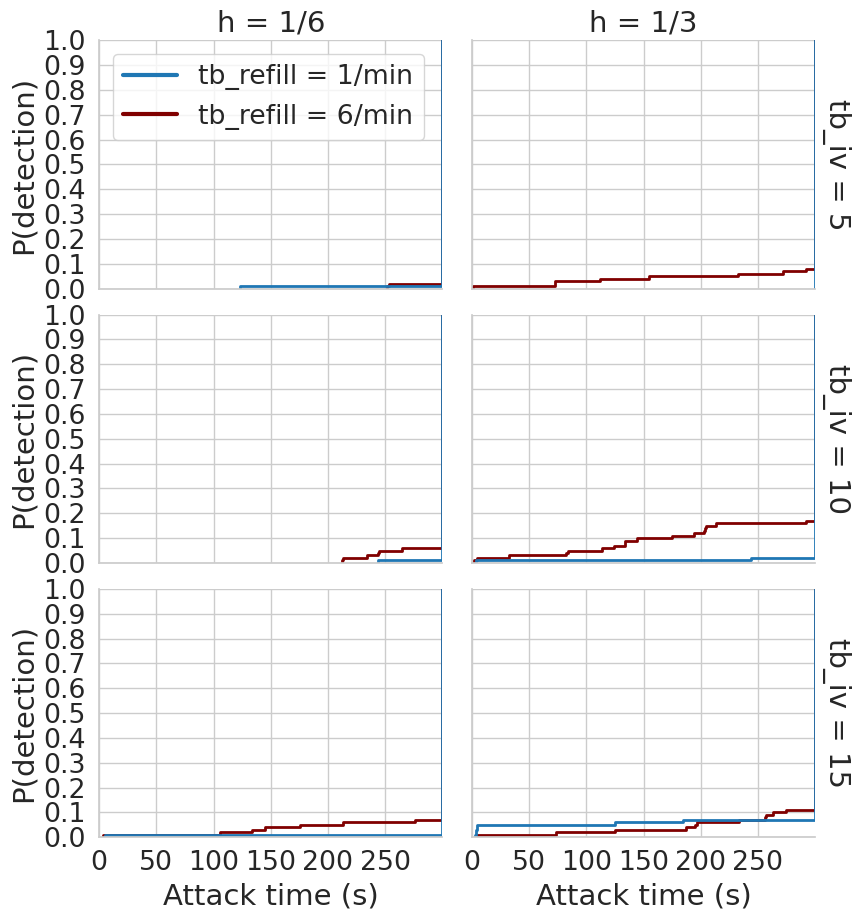

In [11]:
SIMULATION_DURATION = 299.9

sns.set()
sns.set(style="whitegrid", font_scale=1.75)
sns.set_style({"font.family": "Fira Sans Condensed"})

tbr1 = Line2D([0], [0], label = "tb_refill = 1/min", color = "tab:blue", lw = 3.0)
tbr6 = Line2D([0], [0], label = "tb_refill = 6/min", color = "maroon", lw = 3.0)

hue_palette = {0.01666: "tab:blue", 0.1: "maroon"}

fig = sns.displot(
    df_h_one_two, x = "attack_duration", row = "tb_iv", col = "h", hue = "tb_refill",
    kind = "ecdf", height = 3.0, aspect = 1.4, legend = False,
    facet_kws = dict(margin_titles=True), lw = 2.0,
    row_order = (5, 10, 15), col_order = ("1/6", "1/3"),
    palette = hue_palette,
)

fig.set_axis_labels(x_var = "Attack time (s)", y_var = "P(detection)")
fig.set_titles("")

fig.axes[0][0].legend(handles = [tbr1, tbr6], loc = "upper left")

fig.set(xlim=(0.0, SIMULATION_DURATION), ylim=(0.0, 1.0),
        xticks=np.arange(0.0, SIMULATION_DURATION, 50.0),
        yticks=np.arange(0.0, 1.1, 0.1))

plt.tight_layout(pad = 0.0, w_pad = 0.25, h_pad = 0.0)

plt.show()